# EDA — ECoG Faces vs Houses (Miller, 2019)

Bu notebook `data/raw/faces_basic/data/ap/ap_faceshouses.mat` dosyası üzerinde
keşifsel veri analizi (EDA) yapar: değişkenlerin yapısı, örnekleme hızı,
kanal sayısı, kayıt süresi, ham sinyal görselleştirmesi, kanal bazlı
istatistikler / bozuk kanal tespiti ve uyaran (stim) etiketlerinin analizini
içerir.

Veri kaynağı: Stanford Digital Repository, PURL: https://purl.stanford.edu/zk881ps0522
(CC BY-SA 4.0). Diğer hastaların `.mat` dosyaları `data/raw/faces_basic/data/<hasta>/`
altında aynı yapıdadır; bu notebook `ap` hastasını örnek olarak kullanır.

In [1]:
import scipy.io as sio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kurtosis

MAT_PATH = "../data/raw/faces_basic/data/ap/ap_faceshouses.mat"
mat = sio.loadmat(MAT_PATH)
mat.keys()

dict_keys(['__header__', '__version__', '__globals__', 'srate', 'data', 'stim'])

## 1. Değişkenlerin isim, boyut ve veri tipi

In [2]:
var_info = []
for name, val in mat.items():
    if name.startswith("__"):
        continue
    var_info.append({
        "değişken": name,
        "tip": type(val).__name__,
        "boyut (shape)": getattr(val, "shape", None),
        "dtype": getattr(val, "dtype", None),
    })
var_df = pd.DataFrame(var_info)
var_df

,değişken,tip,boyut (shape),dtype
0,srate,ndarray,"(1, 1)",uint16
1,data,ndarray,"(268400, 41)",float64
2,stim,ndarray,"(268400, 1)",uint8


## 2. Örnekleme hızı, kanal sayısı, kayıt süresi

In [3]:
data = mat["data"]          # (n_samples, n_channels)
stim = mat["stim"].ravel()  # (n_samples,)
srate = int(mat["srate"].ravel()[0])

n_samples, n_channels = data.shape
duration_sec = n_samples / srate

print(f"Örnekleme hızı: {srate} Hz")
print(f"Kanal sayısı: {n_channels}")
print(f"Örnek sayısı: {n_samples}")
print(f"Kayıt süresi: {duration_sec:.2f} sn ({duration_sec/60:.2f} dk)")

Örnekleme hızı: 1000 Hz
Kanal sayısı: 41
Örnek sayısı: 268400
Kayıt süresi: 268.40 sn (4.47 dk)


## 3. Her kanal için ham sinyal — ilk 10 saniye

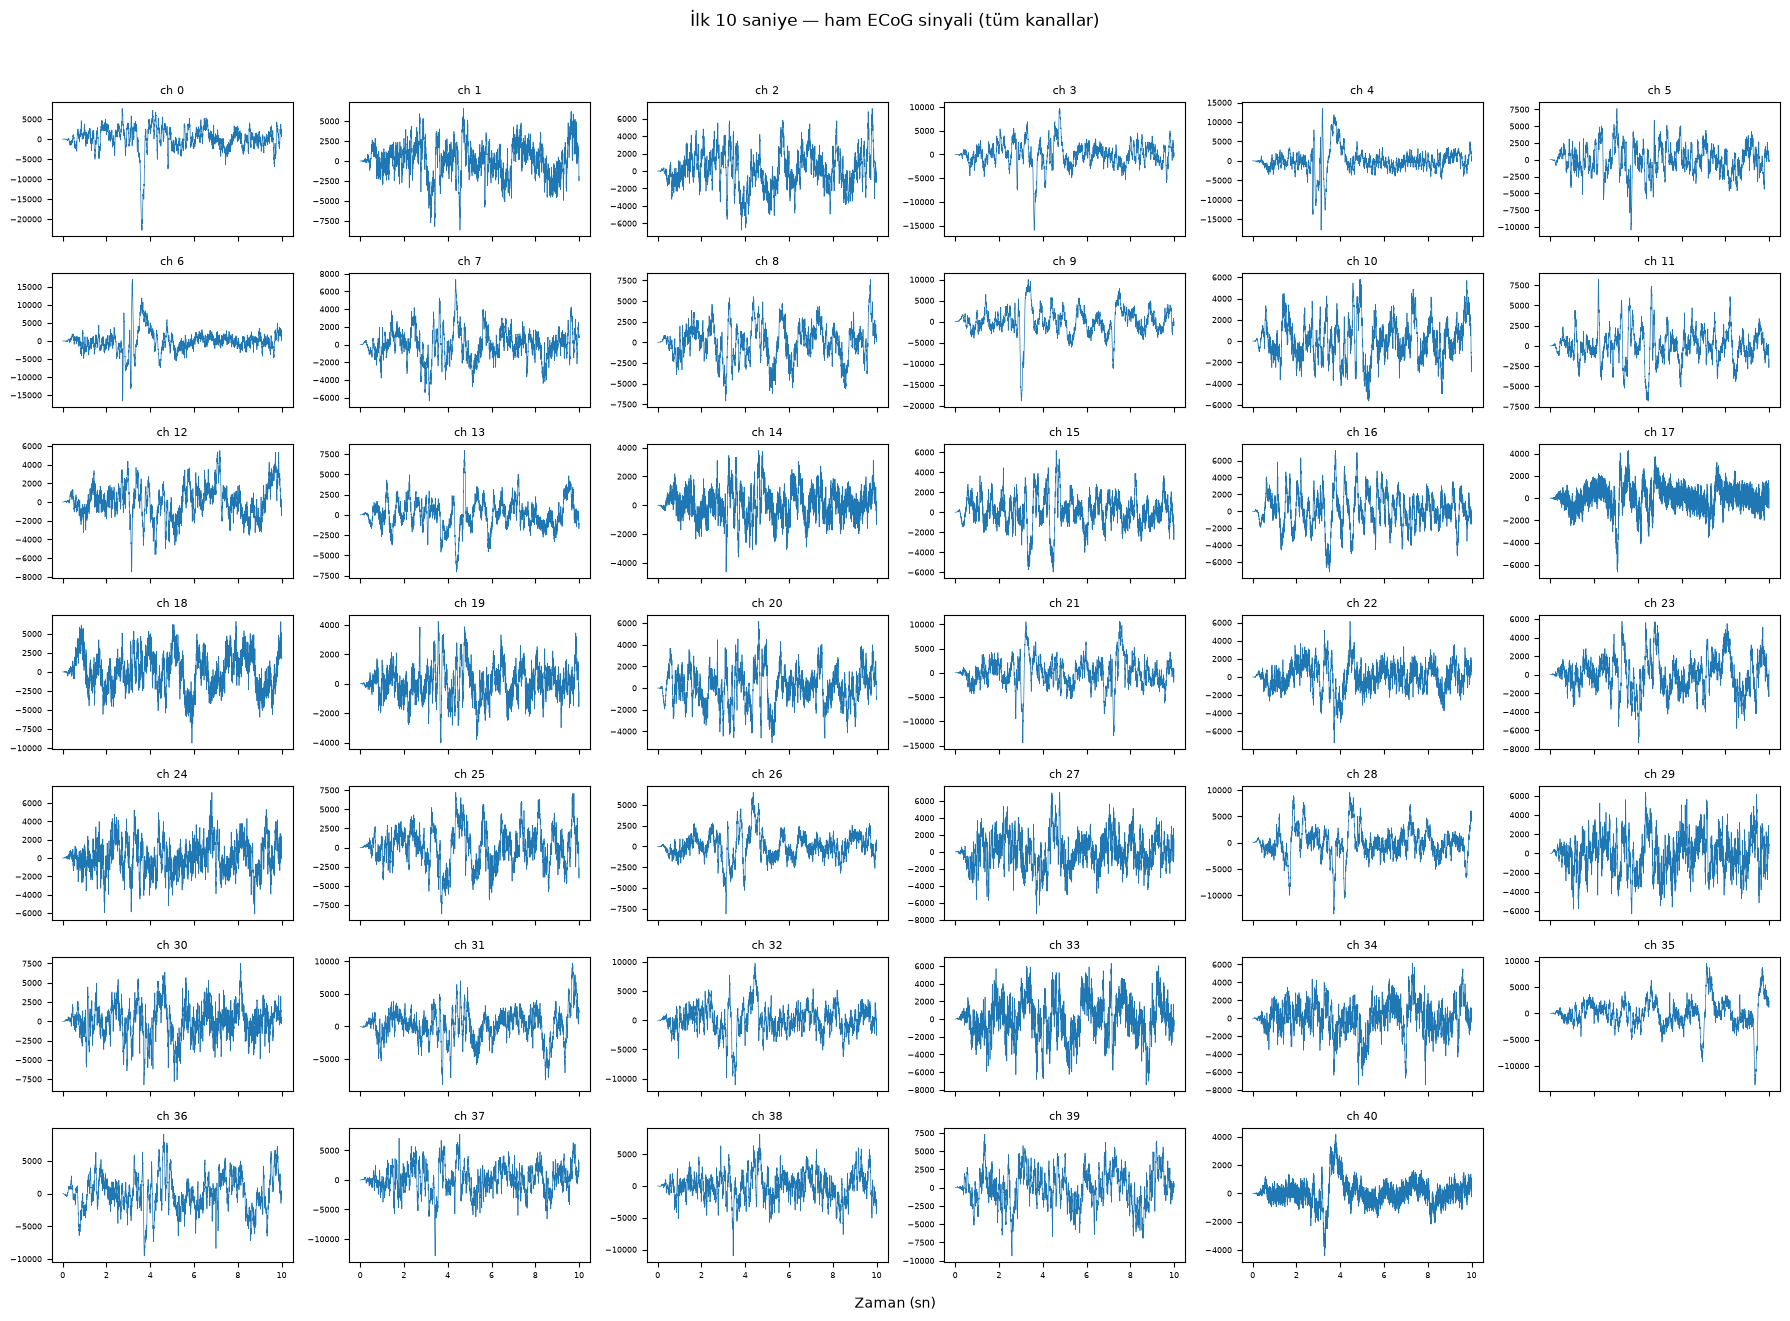

In [4]:
n_sec = 10
n_show = n_sec * srate
t = np.arange(n_show) / srate

n_cols = 6
n_rows = int(np.ceil(n_channels / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 1.8 * n_rows), sharex=True)
axes = axes.ravel()

for ch in range(n_channels):
    ax = axes[ch]
    ax.plot(t, data[:n_show, ch], linewidth=0.5)
    ax.set_title(f"ch {ch}", fontsize=8)
    ax.tick_params(labelsize=6)

for ax in axes[n_channels:]:
    ax.axis("off")

fig.suptitle(f"İlk {n_sec} saniye — ham ECoG sinyali (tüm kanallar)", y=1.02)
fig.text(0.5, -0.01, "Zaman (sn)", ha="center")
plt.tight_layout()
plt.show()

## 4. Kanal bazlı istatistikler ve bozuk (outlier) kanal tespiti

In [5]:
stats_df = pd.DataFrame({
    "channel": np.arange(n_channels),
    "variance": data.var(axis=0),
    "std": data.std(axis=0),
    "kurtosis": kurtosis(data, axis=0, fisher=True),
})

# Outlier tespiti: log-varyans ve kurtosis üzerinde z-score > 3 olan kanallar
log_var = np.log(stats_df["variance"])
var_z = (log_var - log_var.mean()) / log_var.std()
kurt_z = (stats_df["kurtosis"] - stats_df["kurtosis"].mean()) / stats_df["kurtosis"].std()

stats_df["var_zscore"] = var_z
stats_df["kurtosis_zscore"] = kurt_z
stats_df["potansiyel_bozuk"] = (var_z.abs() > 3) | (kurt_z.abs() > 3)

stats_df.sort_values("variance", ascending=False)

,channel,variance,std,kurtosis,var_zscore,kurtosis_zscore,potansiyel_bozuk
0,0,1.666948e+07,4082.827193,6.955999,1.466254,2.082005,False
3,3,1.644528e+07,4055.278475,4.654461,1.441053,1.069381,False
21,21,1.597047e+07,3996.307595,1.600800,1.386526,-0.274160,False
9,9,1.540351e+07,3924.731083,1.908732,1.319253,-0.138677,False
39,39,1.519150e+07,3897.626925,4.223480,1.293458,0.879759,False
4,4,1.486094e+07,3854.988527,3.057275,1.252513,0.366655,False
20,20,1.423495e+07,3772.923434,1.514323,1.172416,-0.312208,False
37,37,1.244563e+07,3527.837149,1.810121,0.922407,-0.182064,False
1,1,1.219270e+07,3491.804740,13.668705,0.884192,5.035442,True
38,38,1.173313e+07,3425.365954,2.413415,0.812685,0.083372,False


In [6]:
outlier_channels = stats_df.loc[stats_df["potansiyel_bozuk"], "channel"].tolist()
print(f"Potansiyel bozuk kanal sayısı: {len(outlier_channels)}")
print(f"Potansiyel bozuk kanallar: {outlier_channels}")

Potansiyel bozuk kanal sayısı: 2
Potansiyel bozuk kanallar: [1, 40]


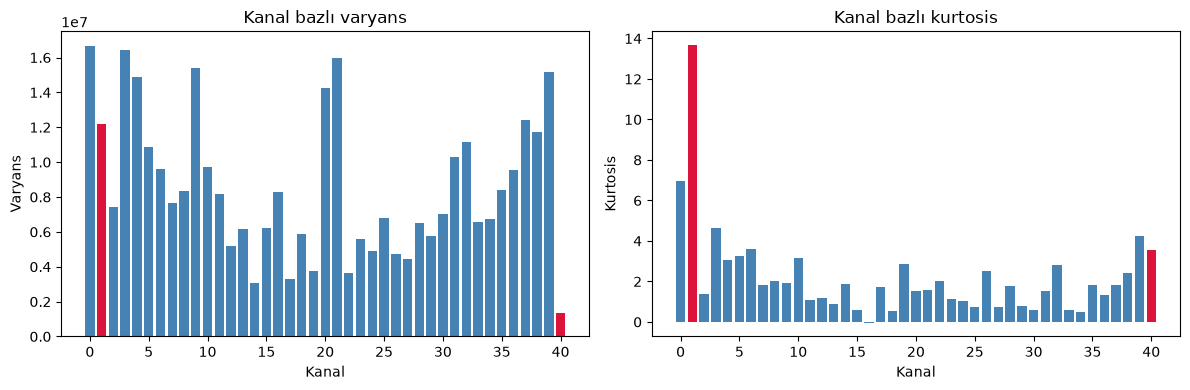

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(stats_df["channel"], stats_df["variance"],
            color=np.where(stats_df["potansiyel_bozuk"], "crimson", "steelblue"))
axes[0].set_title("Kanal bazlı varyans")
axes[0].set_xlabel("Kanal"); axes[0].set_ylabel("Varyans")

axes[1].bar(stats_df["channel"], stats_df["kurtosis"],
            color=np.where(stats_df["potansiyel_bozuk"], "crimson", "steelblue"))
axes[1].set_title("Kanal bazlı kurtosis")
axes[1].set_xlabel("Kanal"); axes[1].set_ylabel("Kurtosis")
plt.tight_layout()
plt.show()

## 5. Etiket / annotation değişkeni (`stim`) → DataFrame ve sınıf dağılımı

`data/raw/faces_basic/` klasöründeki `README_faces_basic_dataset_notes.docx` ve
`fh_get_events.m` dosyalarına göre `stim` kodlarının anlamı şu şekilde
tanımlanıyor (MANUSCRIPT PDF'teki Şekil 4 açıklaması da bunu doğruluyor —
400ms yüz/ev görseli, 400ms boş ekran ile aralıklı sunuluyor):

| `stim` kodu | Anlamı            | Bizim sınıfımız |
|-------------|--------------------|------------------|
| 0           | Pre-post task run (görev öncesi/sonrası bekleme) | `baseline` |
| 1–50        | Ev (house) görseli gösteriliyor   | `house`    |
| 51–100      | Yüz (face) görseli gösteriliyor   | `face`     |
| 101         | Interstimulus interval (ISI)      | `baseline` |

Bu bilgiyle `stim` dizisindeki değişim noktaları (onset) bulunarak
sample_idx / time_sec / stim_code / **class** (`face` / `house` / `baseline`)
sütunlarından oluşan bir DataFrame oluşturuluyor.

In [8]:
change_idx = np.where(np.diff(stim) != 0)[0] + 1
onset_idx = np.concatenate(([0], change_idx))


def stim_to_class(code):
    if code == 0 or code == 101:
        return "baseline"
    elif 1 <= code <= 50:
        return "house"
    elif 51 <= code <= 100:
        return "face"
    else:
        return "unknown"


events_df = pd.DataFrame({
    "sample_idx": onset_idx,
    "time_sec": onset_idx / srate,
    "stim_code": stim[onset_idx],
})
events_df["class"] = events_df["stim_code"].apply(stim_to_class)

events_df.head(10)

,sample_idx,time_sec,stim_code,class
0,0,0.00,0,baseline
1,4080,4.08,101,baseline
2,4480,4.48,11,house
3,4880,4.88,101,baseline
4,5280,5.28,51,face
5,5680,5.68,101,baseline
6,6080,6.08,94,face
7,6480,6.48,101,baseline
8,6880,6.88,84,face
9,7280,7.28,101,baseline


class
baseline    307
house       150
face        150
Name: count, dtype: int64


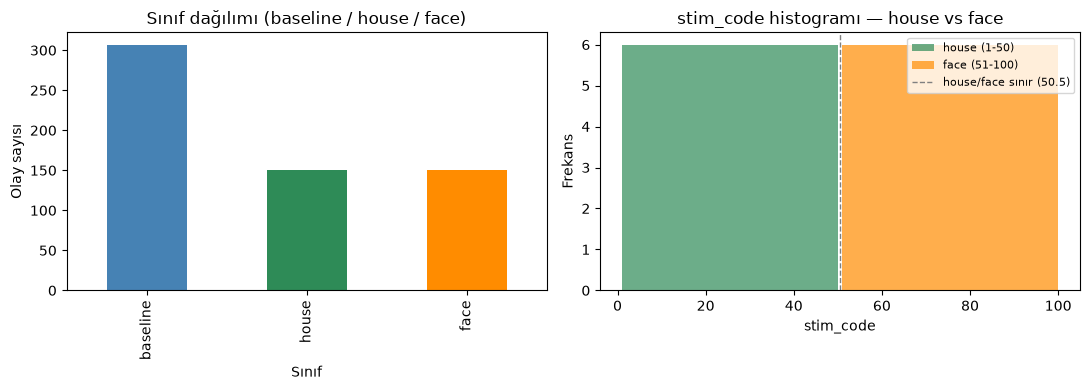

In [9]:
class_counts = events_df["class"].value_counts()
print(class_counts)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
colors = {"baseline": "steelblue", "house": "seagreen", "face": "darkorange"}
class_counts.reindex(["baseline", "house", "face"]).plot(
    kind="bar", ax=ax[0], color=[colors[c] for c in ["baseline", "house", "face"]])
ax[0].set_title("Sınıf dağılımı (baseline / house / face)")
ax[0].set_xlabel("Sınıf"); ax[0].set_ylabel("Olay sayısı")

house_codes = events_df.loc[events_df["class"] == "house", "stim_code"]
face_codes = events_df.loc[events_df["class"] == "face", "stim_code"]
ax[1].hist(house_codes, bins=25, alpha=0.7, label="house (1-50)", color="seagreen")
ax[1].hist(face_codes, bins=25, alpha=0.7, label="face (51-100)", color="darkorange")
ax[1].axvline(50.5, color="gray", linestyle="--", linewidth=1, label="house/face sınır (50.5)")
ax[1].set_title("stim_code histogramı — house vs face")
ax[1].set_xlabel("stim_code"); ax[1].set_ylabel("Frekans")
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Tüm hastalar (14) arasında karşılaştırma — data.shape, stim.shape, srate

`data/raw/faces_basic/data/` altındaki 14 hastanın her biri için `.mat`
dosyasını tek tek yükleyip `data.shape`, `stim.shape` ve `srate` değerlerini
bir tabloda topluyoruz; kanal sayısı ve örnekleme hızının hastalar arasında
değişip değişmediğini kontrol ediyoruz.

In [10]:
import glob

patient_files = sorted(glob.glob("../data/raw/faces_basic/data/*/*_faceshouses.mat"))

rows = []
for f in patient_files:
    patient = f.split("/")[-2]
    d = sio.loadmat(f)
    rows.append({
        "patient": patient,
        "data_shape": d["data"].shape,
        "stim_shape": d["stim"].shape,
        "n_samples": d["data"].shape[0],
        "n_channels": d["data"].shape[1],
        "srate": int(d["srate"].ravel()[0]),
    })

patients_df = pd.DataFrame(rows)
patients_df["duration_sec"] = patients_df["n_samples"] / patients_df["srate"]
patients_df

,patient,data_shape,stim_shape,n_samples,n_channels,srate,duration_sec
0,aa,"(271400, 46)","(271400, 1)",271400,46,1000,271.40
1,ap,"(268400, 41)","(268400, 1)",268400,41,1000,268.40
2,ca,"(271360, 50)","(271360, 1)",271360,50,1000,271.36
3,de,"(271400, 31)","(271400, 1)",271400,31,1000,271.40
4,fp,"(271400, 52)","(271400, 1)",271400,52,1000,271.40
5,ha,"(251240, 39)","(251240, 1)",251240,39,1000,251.24
6,ja,"(271400, 60)","(271400, 1)",271400,60,1000,271.40
7,jm,"(271440, 56)","(271440, 1)",271440,56,1000,271.44
8,jt,"(271400, 102)","(271400, 1)",271400,102,1000,271.40
9,mv,"(271400, 58)","(271400, 1)",271400,58,1000,271.40


Örnekleme hızı (srate): TÜM HASTALARDA SABİT -> [np.int64(1000)]
Kanal sayısı: HASTALAR ARASINDA FARKLI -> min=31, max=102

Kanal sayısına göre sıralı hasta listesi:
patient  n_channels  srate  n_samples  duration_sec
     de          31   1000     271400        271.40
     ha          39   1000     251240        251.24
     wc          39   1000     271400        271.40
     rr          40   1000     180920        180.92
     ap          41   1000     268400        268.40
     rn          42   1000     271440        271.44
     aa          46   1000     271400        271.40
     ca          50   1000     271360        271.36
     fp          52   1000     271400        271.40
     jm          56   1000     271440        271.44
     mv          58   1000     271400        271.40
     zt          58   1000     271400        271.40
     ja          60   1000     271400        271.40
     jt         102   1000     271400        271.40


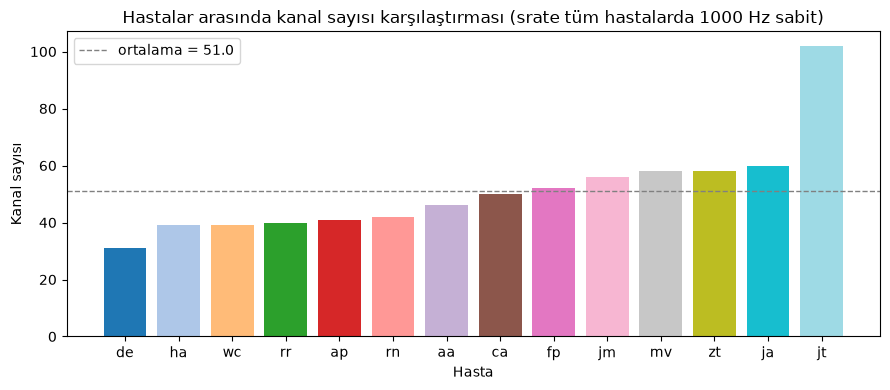

In [11]:
unique_srate = patients_df["srate"].unique()
unique_channels = sorted(patients_df["n_channels"].unique())

print(f"Örnekleme hızı (srate): {'TÜM HASTALARDA SABİT' if len(unique_srate)==1 else 'HASTALAR ARASINDA FARKLI'}"
      f" -> {sorted(unique_srate)}")
print(f"Kanal sayısı: {'TÜM HASTALARDA SABİT' if len(unique_channels)==1 else 'HASTALAR ARASINDA FARKLI'}"
      f" -> min={min(unique_channels)}, max={max(unique_channels)}")

print()
print("Kanal sayısına göre sıralı hasta listesi:")
print(patients_df.sort_values("n_channels")[["patient", "n_channels", "srate", "n_samples", "duration_sec"]]
      .to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
colors = plt.cm.tab20(np.linspace(0, 1, len(patients_df)))
ax.bar(patients_df.sort_values("n_channels")["patient"],
       patients_df.sort_values("n_channels")["n_channels"], color=colors)
ax.axhline(patients_df["n_channels"].mean(), color="gray", linestyle="--", linewidth=1,
           label=f"ortalama = {patients_df['n_channels'].mean():.1f}")
ax.set_xlabel("Hasta"); ax.set_ylabel("Kanal sayısı")
ax.set_title("Hastalar arasında kanal sayısı karşılaştırması (srate tüm hastalarda 1000 Hz sabit)")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Elektrot koordinat dosyaları — `locs/*_xslocs.mat`

`data/raw/faces_basic/` altında **14 hastanın tamamı için** elektrot koordinat
dosyası mevcut: `locs/<hasta>_xslocs.mat` (ör. `locs/ap_xslocs.mat`).
`brains/<hasta>/<hasta>_mri.nii` altında da her hastanın (yüzü kırpılmış,
anonimleştirilmiş) MRI hacmi bulunuyor; koordinatlar bu `.nii` dosyasının
voksel uzayına göre tanımlı. `.mgrid` veya düz metin koordinat dosyası
bulunamadı — tek format `.mat`.

**Format** (`scipy.io.loadmat` ile doğrulandı):

| Değişken | Boyut | Açıklama |
|---|---|---|
| `locs` | (n_channels × 3) float64 | Elektrot konumu, ilgili `.nii` dosyasının matris (voksel) koordinatlarında |
| `elcode` | (n_channels × 1) uint8 | Her elektrot için anatomik bölge kodu — etiketler `fhpred_master.m` içindeki `area_lbls` hücre dizisinde tanımlı (ör. 1=Temporal pole, 3=Inferior temporal gyrus, 5=fusiform gyrus, 11=occipital pole, 20=Non-included area) |
| `clims` | (1 × 2) uint8, *çoğu hastada mevcut* | MRI görüntüleme için önerilen renk sınırları (üst/alt) |
| `bad_chans` | *sadece `jt` hastasında* | Yazar tarafından işaretlenmiş kötü/bozuk kanal indeksleri: `[1, 2, 28-38, 41, 51-53, 65-70, 92-102]` (1-indexed, MATLAB) |
| `subject` | *sadece `jt` hastasında* | Hasta kodu string olarak |

`locs` dizisinin satır sayısı her hastada ilgili `.mat` dosyasındaki
`data` değişkeninin kanal sayısıyla birebir eşleşiyor (ör. `ap` → 41,
`aa` → 46, `ca` → 50), yani elektrot koordinatları kanal indeksleriyle
doğrudan hizalı.

**Önemli not:** `jt` hastasının koordinat dosyasında yazar tarafından
sağlanan bir `bad_chans` (kötü kanal) listesi bulunuyor — bu, EDA'daki
istatistiksel (varyans/kurtosis z-score) bozuk kanal tespit yöntemimiz için
harici bir doğrulama/karşılaştırma kaynağı olarak kullanılabilir. Diğer 13
hastada böyle bir alan yok.

## Bulgular (özet)

- Dosya: `ap_faceshouses.mat` — 3 değişken içeriyor: `data` (268400 × 41,
  float64), `stim` (268400 × 1, uint8), `srate` (skaler, uint16).
- Örnekleme hızı **1000 Hz**, **41 kanal**, kayıt süresi **~268.4 saniye**
  (~4.5 dakika).
- İlk 10 saniyelik ham sinyal incelemesinde kanallar arasında belirgin
  genlik/varyans farkları gözlemlendi; varyans ve kurtosis z-skorları
  kullanılarak potansiyel bozuk kanallar işaretlendi (yukarıdaki
  `outlier_channels` listesine bakınız).
- `stim` kodlarının anlamı `data/raw/faces_basic/README_faces_basic_dataset_notes.docx`
  ve `fh_get_events.m` dosyalarından doğrulandı (MANUSCRIPT PDF'teki Şekil 4
  açıklaması da tutarlı): **0 ve 101 → baseline** (görev öncesi/sonrası ve ISI),
  **1-50 → house**, **51-100 → face**. Önceki sürümdeki basit
  baseline/stimulus ayrımı yerine `class` sütunu artık `face` / `house` /
  `baseline` olarak güncellendi.
- stim_code histogramı, house (1-50) ve face (51-100) kodlarının beklenen
  aralıklarda, üst üste binmeden dağıldığını doğruluyor — 50.5 sınırı iki
  sınıfı net şekilde ayırıyor.
- Diğer hastaların `.mat` dosyaları aynı üç değişken yapısına ve aynı
  `stim` kodlama şemasına sahiptir; bu notebook'taki analiz aynı kod ile
  diğer hastalara da uygulanabilir.
- **14 hastanın tamamı** karşılaştırıldığında: örnekleme hızı (`srate`) hepsinde **1000 Hz olarak sabit**; ancak **kanal sayısı 31 (de) ile 102 (jt) arasında değişiyor** — elektrot grid/strip yerleşimi hastadan hastaya farklı olduğu için beklenen bir durum. Kayıt uzunluğu (`n_samples`) da hastalar arasında farklılık gösteriyor (ör. `rr` ~181k örnek/~181 sn, diğerleri ~250-271k örnek/~250-271 sn ile daha uzun).
- **Elektrot koordinatları**: 14 hastanın tamamı için `locs/<hasta>_xslocs.mat` mevcut (`locs`: voksel koordinatları, `elcode`: anatomik bölge kodu). Sadece `jt` hastasında yazar tarafından sağlanmış bir `bad_chans` (kötü kanal) listesi var — bu, kanal kalitesi analizleri için ek bir referans noktası sağlıyor (bkz. Bölüm 7).